In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("run_results.csv")

In [4]:
df.describe()

,d_model,model_depth,head_dimension,n_heads,d_ffn,vocab_size,n_params_embedding,n_params_encoder,n_params_decoder,n_params_mha,...,embedding_matrix_lr,attention_weight_matrix_lr,attention_bias_lr,w_ffn_in_lr,w_ffn_out_lr,bias_lr,unembedding_matrix_lr,final_loss,best_loss,training_wall_time
count,76.0,76.0,76.0,76.0,76.0,76.0,76.0,76.0,76.0,76.0,...,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000
mean,128.0,24.0,128.0,1.0,512.0,32128.0,4112384.0,4112384.0,4112384.0,16384.0,...,0.015921,0.000124,0.015921,0.000124,0.000031,0.015921,0.000124,9.162075,9.051607,13601.063638
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.019729,0.000154,0.019729,0.000154,0.000039,0.019729,0.000154,41.881029,41.889627,1545.868139
min,128.0,24.0,128.0,1.0,512.0,32128.0,4112384.0,4112384.0,4112384.0,16384.0,...,0.000977,0.000008,0.000977,0.000008,0.000002,0.000977,0.000008,3.830315,3.830315,486.828972
25%,128.0,24.0,128.0,1.0,512.0,32128.0,4112384.0,4112384.0,4112384.0,16384.0,...,0.001808,0.000014,0.001808,0.000014,0.000004,0.001808,0.000014,3.852623,3.852623,13821.464819
50%,128.0,24.0,128.0,1.0,512.0,32128.0,4112384.0,4112384.0,4112384.0,16384.0,...,0.006201,0.000048,0.006201,0.000048,0.000012,0.006201,0.000048,3.895583,3.895583,13851.840220
75%,128.0,24.0,128.0,1.0,512.0,32128.0,4112384.0,4112384.0,4112384.0,16384.0,...,0.021262,0.000166,0.021262,0.000166,0.000042,0.021262,0.000166,4.033128,4.033128,13867.554196
max,128.0,24.0,128.0,1.0,512.0,32128.0,4112384.0,4112384.0,4112384.0,16384.0,...,0.072908,0.000570,0.072908,0.000570,0.000142,0.072908,0.000570,369.361493,369.361493,13982.920307


In [5]:
print(df.columns)

Index(['d_model', 'model_depth', 'head_dimension', 'n_heads', 'd_ffn',
       'vocab_size', 'n_params_embedding', 'n_params_encoder',
       'n_params_decoder', 'n_params_mha', 'n_params_rms_norm', 'n_params_ffn',
       'n_params_transformer_block', 'n_parameters', 'base_lr', 'init_stddev',
       'absolute_init_stddev', 'max_lr', 'lr_schedule_name', 'optim_name',
       'optim_beta1', 'optim_beta2', 'optim_eps', 'weight_decay',
       'n_training_tokens', 'tokens_per_global_batch', 'batch_size',
       'sequence_len', 'n_pretrain_steps', 'n_warmup_steps',
       'embedding_matrix_lr', 'attention_weight_matrix_lr',
       'attention_bias_lr', 'w_ffn_in_lr', 'w_ffn_out_lr', 'bias_lr',
       'unembedding_matrix_lr', 'run_id', 'run_folder_path',
       'run_losses_df_path', 'final_loss', 'best_loss', 'training_wall_time'],
      dtype='object')


In [7]:
print(df['n_pretrain_steps'].unique())
print(df['n_parameters'].unique())

[89208.]
[11766784]


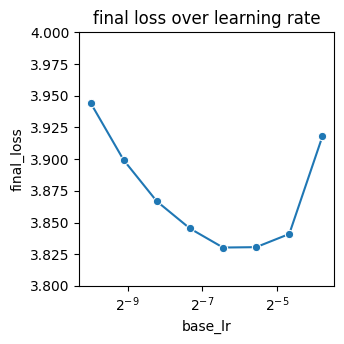

In [27]:
df_min_final_losses = df.groupby('base_lr')['final_loss'].min().reset_index()
fig, ax = plt.subplots(1, 1, figsize=(3.54, 3.54))

# final loss
sns.lineplot(df_min_final_losses,
    x="base_lr",
    y="final_loss",
    ax=ax,
    marker='o',
    )



ax.set_ylim(3.8, 4)

ax.set_xscale("log", base=2)
ax.set_title("final loss over learning rate")

plt.tight_layout()
plt.show()

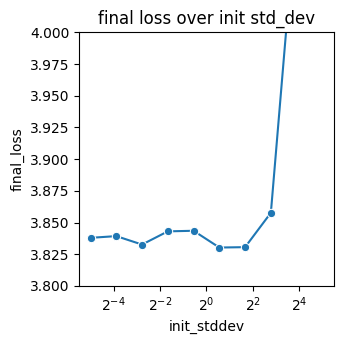

In [30]:
df_min_final_losses = df.groupby('init_stddev')['final_loss'].min().reset_index()
fig, ax = plt.subplots(1, 1, figsize=(3.54, 3.54))

# final loss
sns.lineplot(df_min_final_losses,
    x="init_stddev",
    y="final_loss",
    ax=ax,
    marker='o',
    )



ax.set_ylim(3.8, 4)
ax.set_xscale("log", base=2)

ax.set_title("final loss over init std_dev")

plt.tight_layout()
plt.show()